# FitNova Form-Correction: Overfitting Audit

Re-derives the overfitting-relevant metrics for every trained form-correction model (Squat, OHP, Shallow-Squat; supervised baseline and SSL fine-tune; every seed) from the committed per-epoch curves and per-clip ensemble scores, recomputed in-cell with the same `backend/training/aqa/eval/metrics.py` used to produce the originals. It checks that the stored headline F1 reproduce, that the learning curves show no missed post-best divergence, that the held-out validation-to-test gap is small at both the tuned-threshold F1 and the threshold-free PR-AUC, that confusion and score separation are consistent across splits, that per-seed variance is low, and that the SSL pretraining did not collapse.

Data: the committed `results.pkl` for each exercise, the supervised Squat baseline at `docs/audit/data/squat_baseline_phase03_results.pkl`, and the weight re-evaluation outputs at `docs/audit/data/reeval_*.pkl`. No Drive mount required.

In [1]:
from __future__ import annotations

import hashlib
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Resolve the repository root (robust to the working directory nbconvert runs in).
ROOT = Path.cwd().resolve()
while not (ROOT / "docs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "docs").exists(), f"could not locate repo root from {Path.cwd()}"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from backend.training.aqa.eval.metrics import (  # noqa: E402  (path set above)
    confusion_matrix_per_error,
    f1_per_error,
    pr_auc_per_error,
    threshold_sweep,
)

FIGDIR = ROOT / "docs" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})
C_VAL, C_TEST = "#4C72B0", "#C44E52"      # validation / test
C_POS, C_NEG = "#DD8452", "#55A868"        # positive / negative class
C_TRAIN = "#8172B3"
RNG = np.random.default_rng(20260531)      # fixed seed for bootstrap reproducibility


def savefig(name: str) -> None:
    """Save the current figure to docs/figures/audit_<name>.png before displaying it."""
    path = FIGDIR / f"audit_{name}.png"
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"  saved {path.relative_to(ROOT)}")
    plt.show()
    plt.close()


def load_pkl(rel: str) -> dict:
    p = ROOT / rel
    raw = p.read_bytes()
    md5 = hashlib.md5(raw).hexdigest()[:10]
    print(f"  {rel}\n    {len(raw)/1024:7.1f} KB   md5:{md5}")
    return pickle.loads(raw)


print("Repo root:", ROOT)
print("\nLoading committed artifacts:")
SQUAT = load_pkl("backend/data/benchmark/squat/results.pkl")
OHP = load_pkl("backend/data/benchmark/ohp/results.pkl")
SHAL = load_pkl("backend/data/benchmark/shallow/results.pkl")
SQUAT_BL = load_pkl("docs/audit/data/squat_baseline_phase03_results.pkl")

Repo root: C:\Users\tsh_x\Desktop\fitnova-audit-wt

Loading committed artifacts:
  .planning/phases/04-squat-motion-disentangling-ssl/figures/results.pkl
      250.6 KB   md5:257de5102f
  .planning/phases/06-overhead-press/figures/results.pkl
      391.5 KB   md5:676f440f6a
  .planning/phases/07-image-based-errors-cvcspc/figures/results.pkl
      110.5 KB   md5:076226803f
  docs/audit/data/squat_baseline_phase03_results.pkl
       26.8 KB   md5:fef4aad84a


## Model inventory

The deployed model per exercise is the multi-seed SSL fine-tune ensemble. The baselines are the
supervised controls.

In [2]:
print(f"{'exercise':14s} {'family':22s} {'seeds':>14s}   errors")
print("-" * 70)
print(f"{'Squat':14s} {'supervised baseline':22s} {'[42]':>14s}   KIE, KFE")
print(f"{'Squat':14s} {'MD-SSL fine-tune':22s} {str(list(SQUAT['per_seed'].keys())):>14s}   KIE, KFE")
print(f"{'OHP':14s} {'supervised baseline':22s} {'[42]':>14s}   Elbows, Knees")
print(f"{'OHP':14s} {'MD-SSL fine-tune':22s} {str(list(OHP['finetune_seeds'].keys())):>14s}   Elbows, Knees")
print(f"{'Shallow-Squat':14s} {'supervised baseline':22s} {str(SHAL['seeds']):>14s}   depth")
print(f"{'Shallow-Squat':14s} {'CVCSPC fine-tune':22s} {str(SHAL['seeds']):>14s}   depth")
print()
print("Split sizes (N):")
print(f"  Squat   val={SQUAT['raw']['val_labels'].shape[0]:4d}  test={SQUAT['raw']['test_labels'].shape[0]:4d}")
print(f"  OHP     val={OHP['val_labels'].shape[0]:4d}  test={OHP['test_labels'].shape[0]:4d}")
print(f"  Shallow val={SHAL['val_labels'].shape[0]:4d}  test={SHAL['test_labels'].shape[0]:4d}")

exercise       family                          seeds   errors
----------------------------------------------------------------------
Squat          supervised baseline              [42]   KIE, KFE
Squat          MD-SSL fine-tune        [42, 1337, 7]   KIE, KFE
OHP            supervised baseline              [42]   Elbows, Knees
OHP            MD-SSL fine-tune           [42, 1337]   Elbows, Knees
Shallow-Squat  supervised baseline     [42, 1337, 7]   depth
Shallow-Squat  CVCSPC fine-tune        [42, 1337, 7]   depth

Split sizes (N):
  Squat   val= 243  test= 244
  OHP     val= 339  test= 339
  Shallow val= 529  test= 540


## Section A. Integrity: do the stored headline F1 reproduce from the per-clip scores?

If a headline number were stale or hand-edited, recomputing F1 from the per-clip ensemble scores
at the stored threshold would disagree. We also re-run `threshold_sweep` on the validation scores
and confirm it reproduces the stored production threshold. Column order follows datasets/squat.py
and ohp.py (column 0 = KIE/Elbows, column 1 = KFE/Knees).

In [3]:
def _check(name, got, want, tol=1e-6):
    ok = abs(got - want) <= tol
    flag = "OK " if ok else "!! MISMATCH"
    print(f"  {flag} {name:42s} recomputed={got:.6f}  stored={want:.6f}  d={got-want:+.2e}")
    return ok


all_ok = True
print("SQUAT MD-SSL ensemble (raw per-clip scores, N_val=243, N_test=244)")
sv, svl = SQUAT["raw"]["ens_val_scores"], SQUAT["raw"]["val_labels"]
st, stl = SQUAT["raw"]["ens_test_scores"], SQUAT["raw"]["test_labels"]
for ci, err in [(0, "KIE"), (1, "KFE")]:
    thr = SQUAT["final"]["thresholds"][err]
    f1 = f1_per_error(stl[:, ci], (st[:, ci] >= thr).astype(int))
    all_ok &= _check(f"test F1 {err} at stored thr {thr:.4f}", f1, SQUAT["final"]["test_f1"][err])
    tsw, _ = threshold_sweep(svl[:, ci], sv[:, ci])
    all_ok &= _check(f"val threshold-sweep {err}", tsw, thr, tol=1e-4)

print("\nOHP MD-SSL ensemble (N_val=339, N_test=339)")
ov, ovl = OHP["ensemble_val_scores"], OHP["val_labels"]
ot, otl = OHP["ensemble_test_scores"], OHP["test_labels"]
for ci, err in [(0, "elbows"), (1, "knees")]:
    thr = OHP["thresholds"][err]
    f1 = f1_per_error(otl[:, ci], (ot[:, ci] >= thr).astype(int))
    all_ok &= _check(f"test F1 {err} at stored thr {thr:.4f}", f1, OHP["test_f1"][err])
    tsw, _ = threshold_sweep(ovl[:, ci], ov[:, ci])
    all_ok &= _check(f"val threshold-sweep {err}", tsw, thr, tol=1e-4)

print("\nSHALLOW CVCSPC ensemble (N_val=529, N_test=540)")
thr = SHAL["best_threshold"]
f1 = f1_per_error(SHAL["test_labels"], (SHAL["ensemble_test_scores"] >= thr).astype(int))
all_ok &= _check(f"test F1 depth at stored thr {thr:.4f}", f1, SHAL["test_f1"]["cvcspc_ensemble"])
vf1 = f1_per_error(SHAL["val_labels"], (SHAL["ensemble_val_scores"] >= thr).astype(int))
all_ok &= _check("val F1 depth at stored thr", vf1, SHAL["cvcspc_ensemble_val_f1"])
tsw, _ = threshold_sweep(SHAL["val_labels"], SHAL["ensemble_val_scores"])
all_ok &= _check("val threshold-sweep depth", tsw, thr, tol=1e-4)
print("\nSHALLOW supervised baseline (test scores stored; threshold stored)")
bthr = SHAL["baseline_control"]["threshold"]
bf1 = f1_per_error(SHAL["test_labels"], (SHAL["baseline_control"]["ensemble_test_scores"] >= bthr).astype(int))
all_ok &= _check(f"baseline test F1 depth at thr {bthr:.4f}", bf1, SHAL["baseline_control"]["test_f1"])

print("\nSQUAT supervised baseline (phase-03 val/test scores)")
for ci, err in [(0, "kie"), (1, "kfe")]:
    thr = SQUAT_BL["val_thresholds"][err]
    f1 = f1_per_error(SQUAT_BL["test_labels"][:, ci], (SQUAT_BL["test_scores"][:, ci] >= thr).astype(int))
    all_ok &= _check(f"baseline test F1 {err.upper()} at thr {thr:.4f}", f1, SQUAT_BL[f"test_f1_{err}"])

print("\n" + ("=" * 70))
print("INTEGRITY:", "all stored headline F1 reproduce from per-clip scores [OK]"
      if all_ok else "!! at least one MISMATCH, investigate above")
print("=" * 70)

SQUAT MD-SSL ensemble (raw per-clip scores, N_val=243, N_test=244)
  OK  test F1 KIE at stored thr 0.6145           recomputed=0.419753  stored=0.419753  d=+0.00e+00
  OK  val threshold-sweep KIE                    recomputed=0.614487  stored=0.614487  d=+0.00e+00
  OK  test F1 KFE at stored thr 0.3847           recomputed=0.841026  stored=0.841026  d=+0.00e+00
  OK  val threshold-sweep KFE                    recomputed=0.384650  stored=0.384650  d=+0.00e+00

OHP MD-SSL ensemble (N_val=339, N_test=339)
  OK  test F1 elbows at stored thr 0.3574        recomputed=0.447368  stored=0.447368  d=+0.00e+00
  OK  val threshold-sweep elbows                 recomputed=0.357355  stored=0.357355  d=+0.00e+00
  OK  test F1 knees at stored thr 0.4765         recomputed=0.877049  stored=0.877049  d=+0.00e+00
  OK  val threshold-sweep knees                  recomputed=0.476475  stored=0.476475  d=+0.00e+00

SHALLOW CVCSPC ensemble (N_val=529, N_test=540)
  OK  test F1 depth at stored thr 0.3954       

## Section B. Learning curves (train vs validation) with the best epoch marked

An overfitting run shows the training loss falling while the validation loss rises past the best
epoch, with the checkpoint taken after the rise. For each run we mark the epoch the deployed
`best.pt` was taken at (argmax of the validation metric used for early stopping) and report the
change in validation loss from that epoch to the final epoch. The full curve to the early-stop
point is used, not the best.pt-frozen history. BCE validation loss and validation F1 decouple under
class imbalance, so a rising validation loss is not by itself the deployment metric degrading; the
held-out F1 gap in Section C is the relevant test.

  saved docs\figures\audit_squat_learning_curves.png


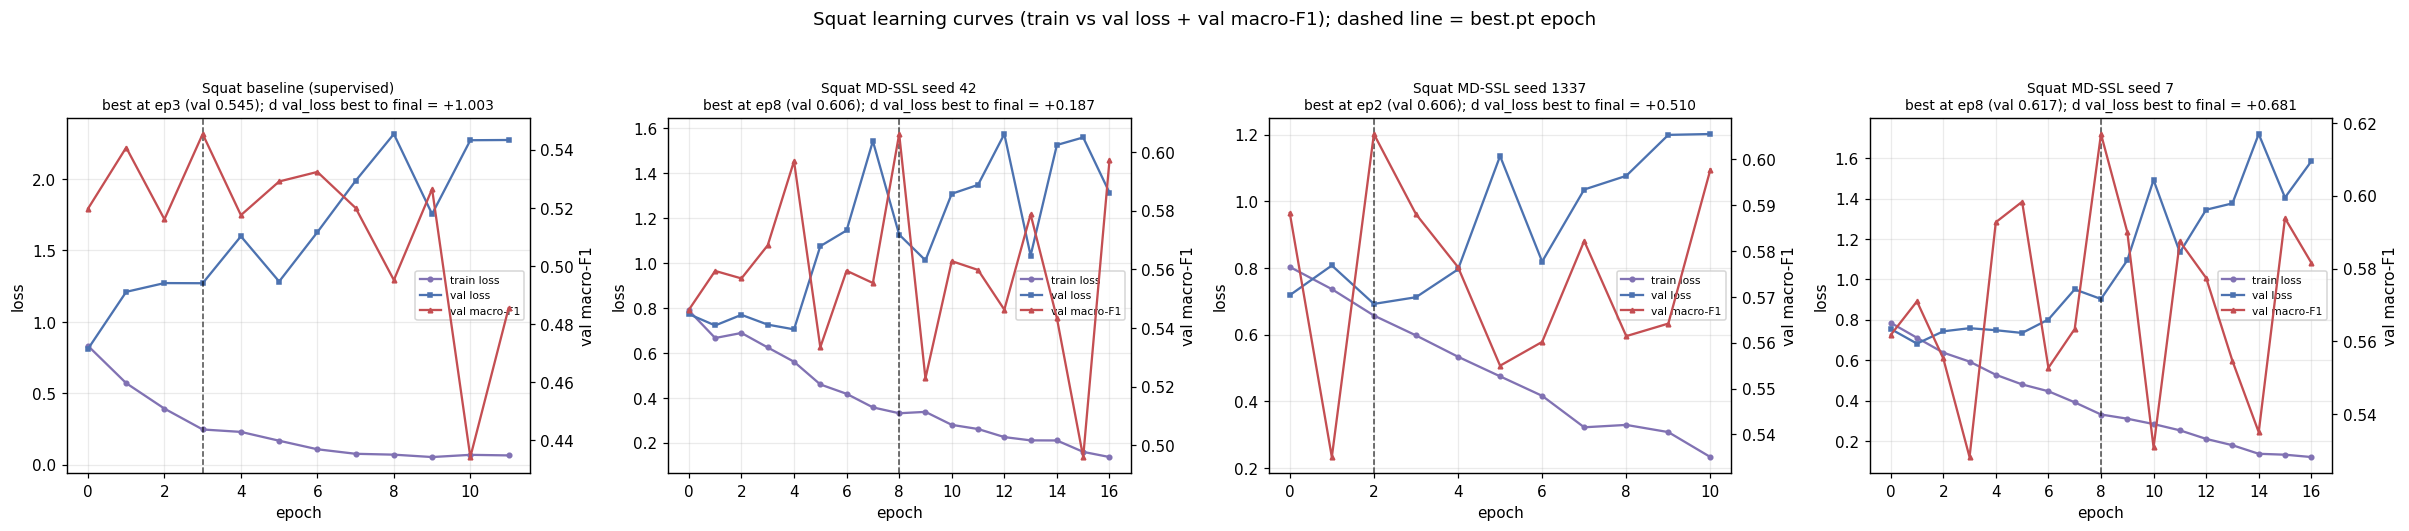

  saved docs\figures\audit_ohp_learning_curves.png


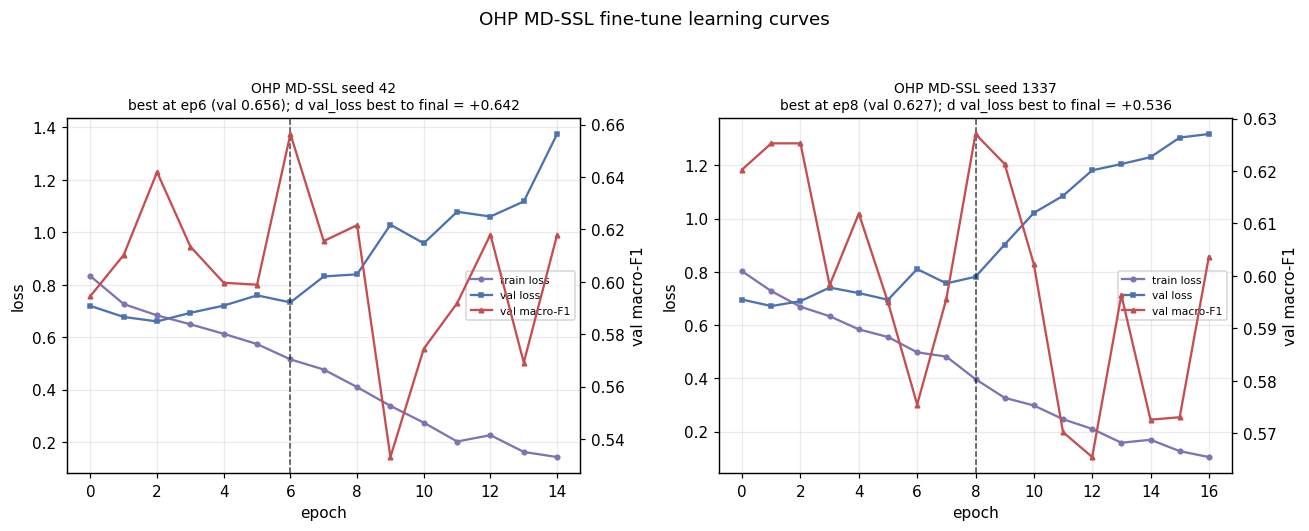

  saved docs\figures\audit_shallow_learning_curves.png


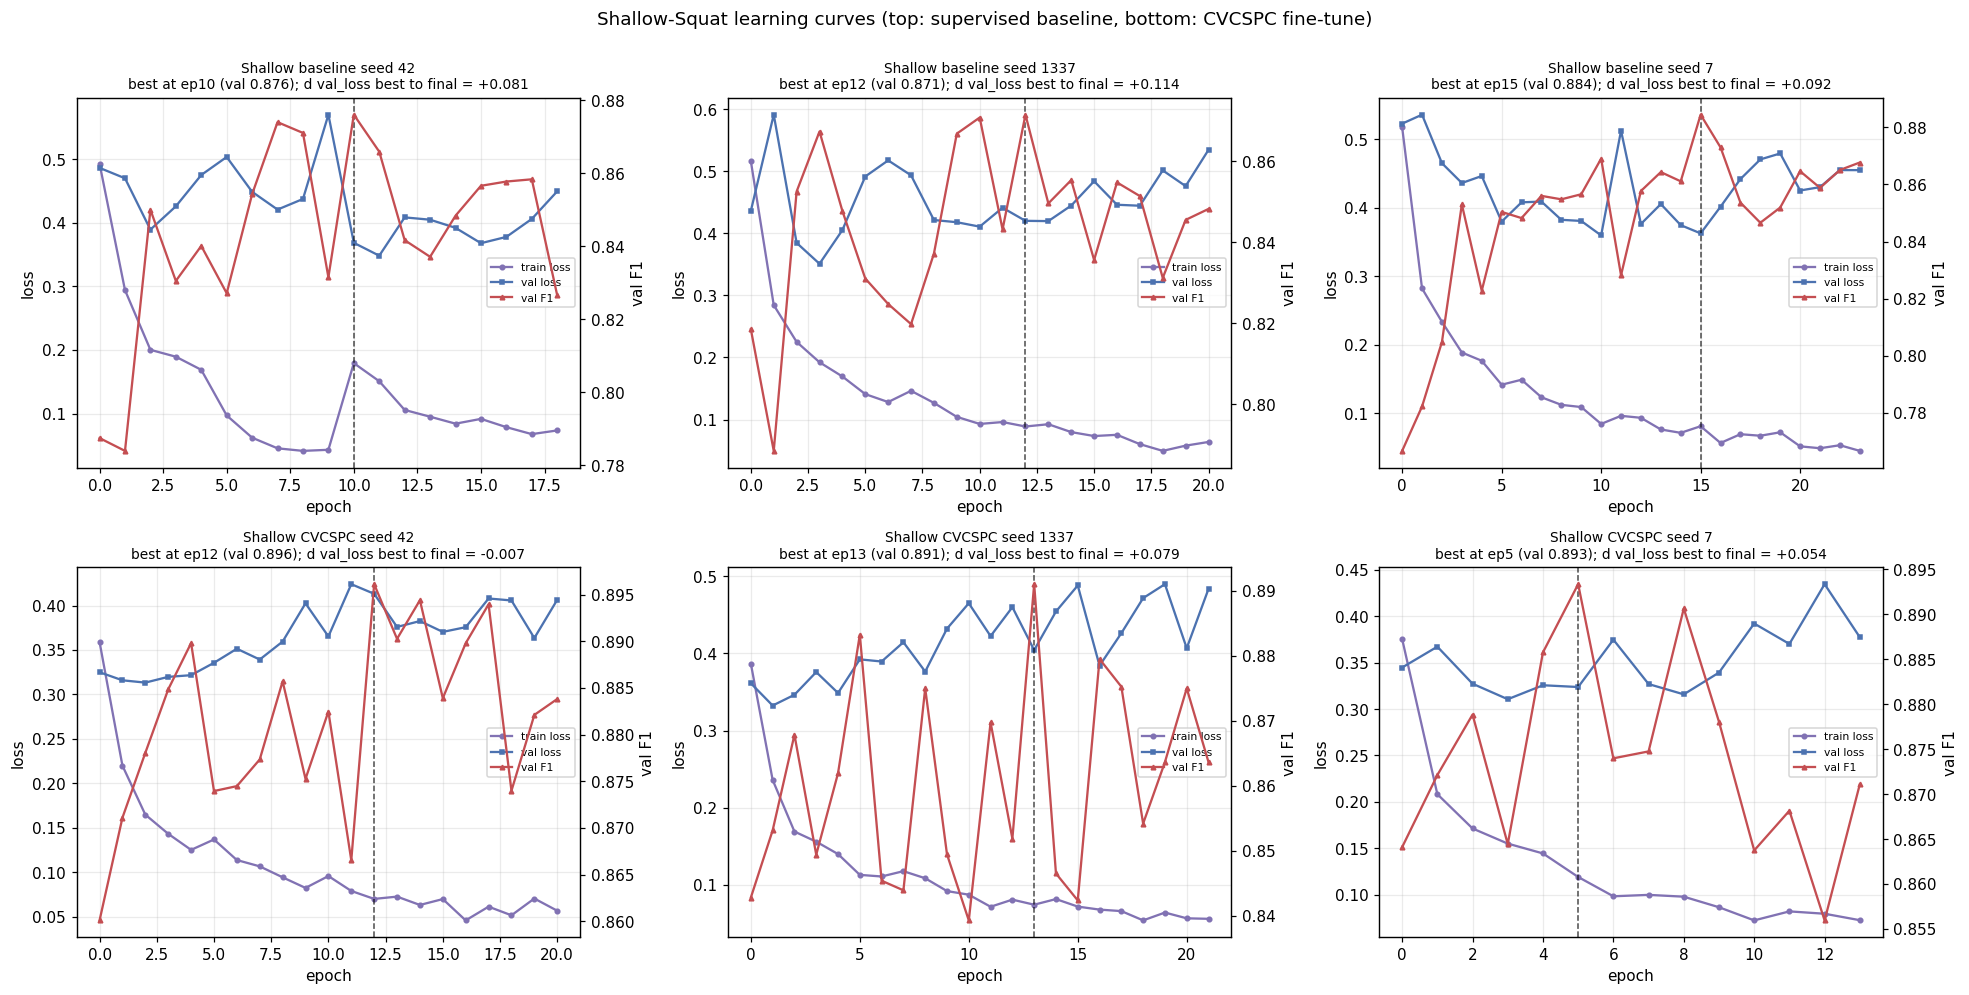


Post-best divergence (d val_loss best to final; a positive value with falling train loss
means the model would overfit if trained further):
model                        best_ep final_ep  d_val_loss  d_train_loss
squat/baseline/seed42              3       11      +1.003        -0.182
squat/mdssl/seed42                 8       16      +0.187        -0.195
squat/mdssl/seed1337               2       10      +0.510        -0.425
squat/mdssl/seed7                  8       16      +0.681        -0.211
ohp/mdssl/seed42                   6       14      +0.642        -0.373
ohp/mdssl/seed1337                 8       16      +0.536        -0.293
shallow/baseline/seed42           10       18      +0.081        -0.106
shallow/baseline/seed1337         12       20      +0.114        -0.025
shallow/baseline/seed7            15       23      +0.092        -0.036
shallow/cvcspc/seed42             12       20      -0.007        -0.013
shallow/cvcspc/seed1337           13       21      +0.079        -0

In [4]:
def curve(hist, val_key):
    ep = np.array([h["epoch"] for h in hist])
    tr = np.array([h["train_loss_mean"] for h in hist], float)
    vl = np.array([h["val_loss_mean"] for h in hist], float)
    vf = np.array([h[val_key] for h in hist], float)
    return ep, tr, vl, vf


def plot_curve(ax, hist, val_key, title, val_label="val macro-F1"):
    ep, tr, vl, vf = curve(hist, val_key)
    best = int(np.argmax(vf))
    ax.plot(ep, tr, color=C_TRAIN, marker="o", ms=3, lw=1.5, label="train loss")
    ax.plot(ep, vl, color=C_VAL, marker="s", ms=3, lw=1.5, label="val loss")
    ax.axvline(ep[best], color="k", ls="--", lw=1, alpha=0.7)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax2 = ax.twinx()
    ax2.plot(ep, vf, color=C_TEST, marker="^", ms=3, lw=1.5, label=val_label)
    ax2.set_ylabel(val_label)
    ax2.grid(False)
    dvl = vl[-1] - vl[best]
    ax.set_title(f"{title}\nbest at ep{ep[best]} (val {vf[best]:.3f}); "
                 f"d val_loss best to final = {dvl:+.3f}", fontsize=9)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=7, loc="center right")
    return dict(best_epoch=int(ep[best]), final_epoch=int(ep[-1]), val_best=float(vf[best]),
                dval_loss_best_to_final=float(dvl),
                train_loss_best=float(tr[best]), train_loss_final=float(tr[-1]),
                val_loss_best=float(vl[best]), val_loss_final=float(vl[-1]))


curve_summary = {}

fig, axes = plt.subplots(1, 4, figsize=(22, 4.6))
curve_summary["squat/baseline/seed42"] = plot_curve(
    axes[0], SQUAT_BL["metrics_history"], "val_macro_f1", "Squat baseline (supervised)")
for ax, seed in zip(axes[1:], SQUAT["finetune_curves"]):
    curve_summary[f"squat/mdssl/seed{seed}"] = plot_curve(
        ax, SQUAT["finetune_curves"][seed], "val_macro_f1", f"Squat MD-SSL seed {seed}")
plt.suptitle("Squat learning curves (train vs val loss + val macro-F1); dashed line = best.pt epoch", y=1.04)
savefig("squat_learning_curves")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, seed in zip(axes, OHP["finetune_seeds"]):
    curve_summary[f"ohp/mdssl/seed{seed}"] = plot_curve(
        ax, OHP["finetune_seeds"][seed], "val_macro_f1", f"OHP MD-SSL seed {seed}")
plt.suptitle("OHP MD-SSL fine-tune learning curves", y=1.04)
savefig("ohp_learning_curves")

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, seed in zip(axes[0], SHAL["baseline_seeds"]):
    curve_summary[f"shallow/baseline/seed{seed}"] = plot_curve(
        ax, SHAL["baseline_seeds"][seed], "val_f1", f"Shallow baseline seed {seed}", "val F1")
for ax, seed in zip(axes[1], SHAL["finetune_seeds"]):
    curve_summary[f"shallow/cvcspc/seed{seed}"] = plot_curve(
        ax, SHAL["finetune_seeds"][seed], "val_f1", f"Shallow CVCSPC seed {seed}", "val F1")
plt.suptitle("Shallow-Squat learning curves (top: supervised baseline, bottom: CVCSPC fine-tune)", y=1.0)
savefig("shallow_learning_curves")

print("\nPost-best divergence (d val_loss best to final; a positive value with falling train loss")
print("means the model would overfit if trained further):")
print(f"{'model':28s} {'best_ep':>7s} {'final_ep':>8s} {'d_val_loss':>11s} {'d_train_loss':>13s}")
for k, v in curve_summary.items():
    dtr = v["train_loss_final"] - v["train_loss_best"]
    print(f"{k:28s} {v['best_epoch']:7d} {v['final_epoch']:8d} "
          f"{v['dval_loss_best_to_final']:+11.3f} {dtr:+13.3f}")

## Section C. Held-out generalization (validation to test)

The operating threshold is tuned on validation, so validation F1 is the threshold-maximised value
and is biased upward by selection; a modest validation-above-test F1 gap is therefore expected from
threshold selection alone, not only from overfitting. We report two signals:

1. The validation-to-test F1 gap at the val-tuned threshold, with 95% bootstrap CIs on both splits
   (rare classes such as Squat KIE and OHP Elbows carry large sampling noise on tens of positives).
2. The validation-to-test PR-AUC gap, which is threshold-free and isolates ranking generalization
   from threshold selection. A small PR-AUC gap means the model orders positives above negatives
   equally well on both splits, so any residual F1 gap is selection plus finite-sample noise.

A row generalizes when the validation value does not exceed the test value by more than 0.03 and by
more than the test bootstrap CI, on both F1 and PR-AUC. The supervised baselines are included as
controls. The OHP baseline is loaded from the weight re-evaluation to show a real overfitting case.

model and error           val_F1  test_F1   F1gap  valPRAUC  tstPRAUC  PRAUCgap   tst PRAUC 95%CI  generalizes?
------------------------------------------------------------------------------------------------------------------------
Squat MD-SSL - KIE        0.5000   0.4198 +0.0802    0.5195    0.3875   +0.1320  [0.267,0.557]   YES
Squat MD-SSL - KFE        0.8128   0.8410 -0.0282    0.8343    0.8812   -0.0469  [0.830,0.924]   YES
Squat baseline - KIE      0.3040   0.2857 +0.0183    0.1938    0.2645   -0.0707  [0.151,0.404]   YES
Squat baseline - KFE      0.7979   0.8000 -0.0021    0.7019    0.7640   -0.0621  [0.695,0.838]   YES
OHP MD-SSL - Elbows       0.4780   0.4474 +0.0306    0.3682    0.3694   -0.0012  [0.288,0.472]   YES
OHP MD-SSL - Knees        0.8683   0.8770 -0.0088    0.9387    0.9372   +0.0015  [0.906,0.962]   YES
Shallow CVCSPC - depth    0.9119   0.8902 +0.0217    0.9620    0.9668   -0.0048  [0.949,0.980]   YES
Shallow baseline - depth  0.8942   0.8750 +0.0192    n/a    

  saved docs\figures\audit_val_test_gap_summary.png


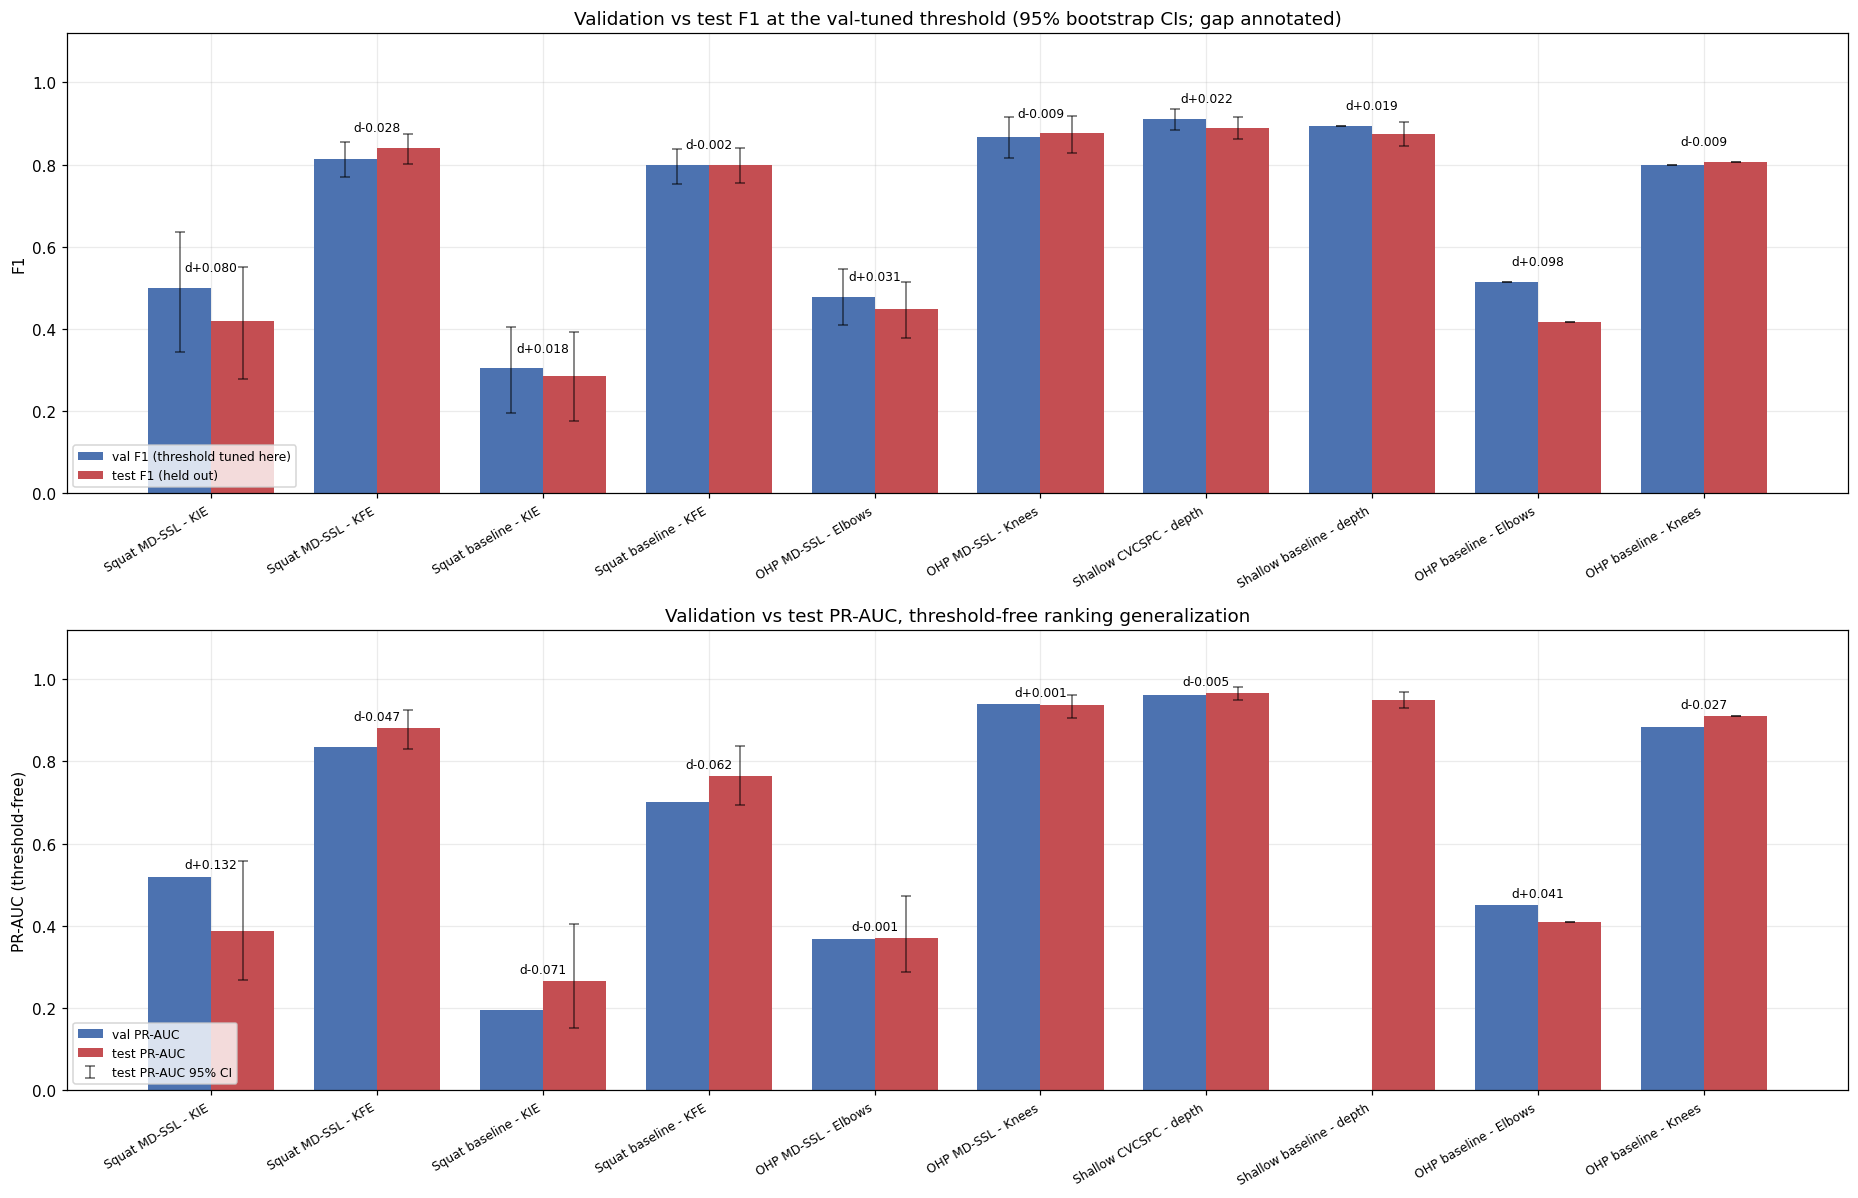

In [5]:
def f1_at(labels, scores, thr):
    return f1_per_error(labels, (scores >= thr).astype(int))


def boot_f1_ci(labels, scores, thr, n=2000):
    labels = np.asarray(labels); scores = np.asarray(scores)
    N = len(labels); out = np.empty(n)
    for i in range(n):
        idx = RNG.integers(0, N, N)
        out[i] = f1_per_error(labels[idx], (scores[idx] >= thr).astype(int))
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))


def boot_prauc_ci(labels, scores, n=2000):
    labels = np.asarray(labels); scores = np.asarray(scores)
    N = len(labels); out = []
    for _ in range(n):
        idx = RNG.integers(0, N, N)
        lab = labels[idx]
        if 0 < lab.sum() < len(lab):
            out.append(pr_auc_per_error(lab, scores[idx]))
    out = np.array(out)
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))


gap_rows = []


def add_gap(label, vlab, vsc, tlab, tsc, thr):
    vf, tf = f1_at(vlab, vsc, thr), f1_at(tlab, tsc, thr)
    vlo, vhi = boot_f1_ci(vlab, vsc, thr)
    tlo, thi = boot_f1_ci(tlab, tsc, thr)
    vpr, tpr = pr_auc_per_error(vlab, vsc), pr_auc_per_error(tlab, tsc)
    tpr_lo, tpr_hi = boot_prauc_ci(tlab, tsc)
    # Directional and noise-aware: overfitting means validation exceeds test by more than 0.03 and
    # beyond the test bootstrap CI. A test value at or above validation never indicates overfitting.
    f1_ok = (vf - tf <= 0.03) or (vf <= thi)
    pr_ok = (vpr - tpr <= 0.03) or (vpr <= tpr_hi)
    gap_rows.append(dict(label=label, vf1=vf, tf1=tf, f1_gap=vf - tf, vlo=vlo, vhi=vhi,
                         tlo=tlo, thi=thi, vpr=vpr, tpr=tpr, prauc_gap=vpr - tpr,
                         tpr_lo=tpr_lo, tpr_hi=tpr_hi, ok=(f1_ok and pr_ok), deployed=True))


for ci, err in [(0, "KIE"), (1, "KFE")]:
    add_gap(f"Squat MD-SSL - {err}", svl[:, ci], sv[:, ci], stl[:, ci], st[:, ci],
            SQUAT["final"]["thresholds"][err])
for ci, err in [(0, "KIE"), (1, "KFE")]:
    add_gap(f"Squat baseline - {err}", SQUAT_BL["val_labels"][:, ci], SQUAT_BL["val_scores"][:, ci],
            SQUAT_BL["test_labels"][:, ci], SQUAT_BL["test_scores"][:, ci],
            SQUAT_BL["val_thresholds"][err.lower()])
gap_rows[-1]["deployed"] = gap_rows[-2]["deployed"] = False
for ci, err in [(0, "Elbows"), (1, "Knees")]:
    add_gap(f"OHP MD-SSL - {err}", ovl[:, ci], ov[:, ci], otl[:, ci], ot[:, ci],
            OHP["thresholds"][err.lower()])
add_gap("Shallow CVCSPC - depth", SHAL["val_labels"], SHAL["ensemble_val_scores"],
        SHAL["test_labels"], SHAL["ensemble_test_scores"], SHAL["best_threshold"])
# Shallow baseline: only the stored validation F1 is available (no validation score array).
_b = SHAL["baseline_control"]
_bt = f1_at(SHAL["test_labels"], _b["ensemble_test_scores"], _b["threshold"])
_btlo, _bthi = boot_f1_ci(SHAL["test_labels"], _b["ensemble_test_scores"], _b["threshold"])
_btpr_lo, _btpr_hi = boot_prauc_ci(SHAL["test_labels"], _b["ensemble_test_scores"])
gap_rows.append(dict(label="Shallow baseline - depth", vf1=_b["ensemble_val_f1"], tf1=_bt,
                     f1_gap=_b["ensemble_val_f1"] - _bt, vlo=np.nan, vhi=np.nan,
                     tlo=_btlo, thi=_bthi, vpr=np.nan,
                     tpr=pr_auc_per_error(SHAL["test_labels"], _b["ensemble_test_scores"]),
                     prauc_gap=np.nan, tpr_lo=_btpr_lo, tpr_hi=_btpr_hi, deployed=False,
                     ok=((_b["ensemble_val_f1"] - _bt <= 0.03) or (_b["ensemble_val_f1"] <= _bthi))))

# OHP supervised baseline: loaded from the weight re-evaluation (the committed results.pkl stored
# only its summary F1). This control is the one model that overfits, included so the figure shows it.
_rv_path = ROOT / "docs/audit/data/reeval_video.pkl"
if _rv_path.exists():
    _rv = pickle.loads(_rv_path.read_bytes())
    for _e, _name in [("elbows", "Elbows"), ("knees", "Knees")]:
        _pe = _rv["ohp_baseline"]["per_error"][_e]
        _vf, _tf = float(_pe["val_f1"]), float(_pe["test_f1"])
        _vpr, _tpr = float(_pe["val_prauc"]), float(_pe["test_prauc"])
        _ok = ((_vf - _tf <= 0.03) or (_vf <= _tf)) and ((_vpr - _tpr <= 0.03) or (_vpr <= _tpr))
        gap_rows.append(dict(label=f"OHP baseline - {_name}", vf1=_vf, tf1=_tf, f1_gap=_vf - _tf,
                             vlo=_vf, vhi=_vf, tlo=_tf, thi=_tf, vpr=_vpr, tpr=_tpr,
                             prauc_gap=_vpr - _tpr, tpr_lo=_tpr, tpr_hi=_tpr, deployed=False, ok=_ok))

print(f"{'model and error':24s} {'val_F1':>7s} {'test_F1':>8s} {'F1gap':>7s} "
      f"{'valPRAUC':>9s} {'tstPRAUC':>9s} {'PRAUCgap':>9s} {'tst PRAUC 95%CI':>17s}  generalizes?")
print("-" * 120)
for r in gap_rows:
    vpr = "   n/a  " if np.isnan(r["vpr"]) else f"{r['vpr']:9.4f}"
    pg = "   n/a  " if np.isnan(r["prauc_gap"]) else f"{r['prauc_gap']:+9.4f}"
    print(f"{r['label']:24s} {r['vf1']:7.4f} {r['tf1']:8.4f} {r['f1_gap']:+7.4f} "
          f"{vpr} {r['tpr']:9.4f} {pg}  [{r['tpr_lo']:.3f},{r['tpr_hi']:.3f}]   {'YES' if r['ok'] else 'REVIEW'}")
_kie = next(r for r in gap_rows if r["label"] == "Squat MD-SSL - KIE")
print(f"\nNote: Squat MD-SSL KIE is the rarest class (36 test positives). Its validation PR-AUC "
      f"{_kie['vpr']:.3f} sits {'inside' if _kie['vpr'] <= _kie['tpr_hi'] else 'above'} the test "
      f"PR-AUC 95% CI [{_kie['tpr_lo']:.3f},{_kie['tpr_hi']:.3f}];\n  the test KIE F1 {_kie['tf1']:.3f} "
      f"equals the paper MD KIE F1 {SQUAT['comparison']['paper_md']['KIE']:.3f} (the difficulty "
      f"ceiling, not below it).")

# Figure: validation vs test F1 (top) and PR-AUC (bottom).
labels = [r["label"] for r in gap_rows]
x = np.arange(len(labels)); w = 0.38
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(17, 11))
vals = np.array([r["vf1"] for r in gap_rows]); tests = np.array([r["tf1"] for r in gap_rows])
v_err = np.array([[r["vf1"] - (r["vf1"] if np.isnan(r["vlo"]) else r["vlo"]),
                   (r["vf1"] if np.isnan(r["vhi"]) else r["vhi"]) - r["vf1"]] for r in gap_rows]).T
t_err = np.array([[r["tf1"] - r["tlo"], r["thi"] - r["tf1"]] for r in gap_rows]).T
ax1.bar(x - w/2, vals, w, color=C_VAL, label="val F1 (threshold tuned here)")
ax1.bar(x + w/2, tests, w, color=C_TEST, label="test F1 (held out)")
ax1.errorbar(x - w/2, vals, yerr=v_err, fmt="none", ecolor="k", elinewidth=1, capsize=3, alpha=0.6)
ax1.errorbar(x + w/2, tests, yerr=t_err, fmt="none", ecolor="k", elinewidth=1, capsize=3, alpha=0.6)
for xi, r in enumerate(gap_rows):
    ax1.text(xi, max(r["vf1"], r["tf1"]) + 0.04, f"d{r['f1_gap']:+.3f}", ha="center", fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax1.set_ylabel("F1"); ax1.set_ylim(0, 1.12)
ax1.set_title("Validation vs test F1 at the val-tuned threshold (95% bootstrap CIs; gap annotated)")
ax1.legend(loc="lower left", fontsize=8)
vpr = np.array([r["vpr"] for r in gap_rows]); tpr = np.array([r["tpr"] for r in gap_rows])
ax2.bar(x - w/2, np.nan_to_num(vpr), w, color=C_VAL, label="val PR-AUC")
ax2.bar(x + w/2, tpr, w, color=C_TEST, label="test PR-AUC")
tpr_err = np.array([[r["tpr"] - r["tpr_lo"], r["tpr_hi"] - r["tpr"]] for r in gap_rows]).T
ax2.errorbar(x + w/2, tpr, yerr=tpr_err, fmt="none", ecolor="k", elinewidth=1, capsize=3, alpha=0.6,
             label="test PR-AUC 95% CI")
for xi, r in enumerate(gap_rows):
    if not np.isnan(r["prauc_gap"]):
        ax2.text(xi, np.nanmax([r["vpr"], r["tpr"]]) + 0.02, f"d{r['prauc_gap']:+.3f}", ha="center", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("PR-AUC (threshold-free)"); ax2.set_ylim(0, 1.12)
ax2.set_title("Validation vs test PR-AUC, threshold-free ranking generalization")
ax2.legend(loc="lower left", fontsize=8)
savefig("val_test_gap_summary")

## Section C2. ROC curves and AUC-ROC (validation vs test)

ROC curves and the area under them for each deployed error, on validation and test. Validation and
test curves lying close together is another view of generalization. AUC-ROC is optimistic under
class imbalance (the large negative set keeps the false-positive rate low), so for the rare error
classes it reads much higher than the PR-AUC in Section C. PR-AUC is the stricter minority-class
measure and F1 is the metric the reference paper reports; both are provided here.

error             val AUC-ROC  test AUC-ROC      gap    test PR-AUC (ref)
--------------------------------------------------------------------------
Squat KIE               0.790         0.784   +0.006              0.388
Squat KFE               0.737         0.770   -0.033              0.881
OHP Elbows              0.677         0.638   +0.039              0.369
OHP Knees               0.958         0.940   +0.019              0.937
Shallow depth           0.966         0.973   -0.007              0.967


  saved docs\figures\audit_roc_curves.png


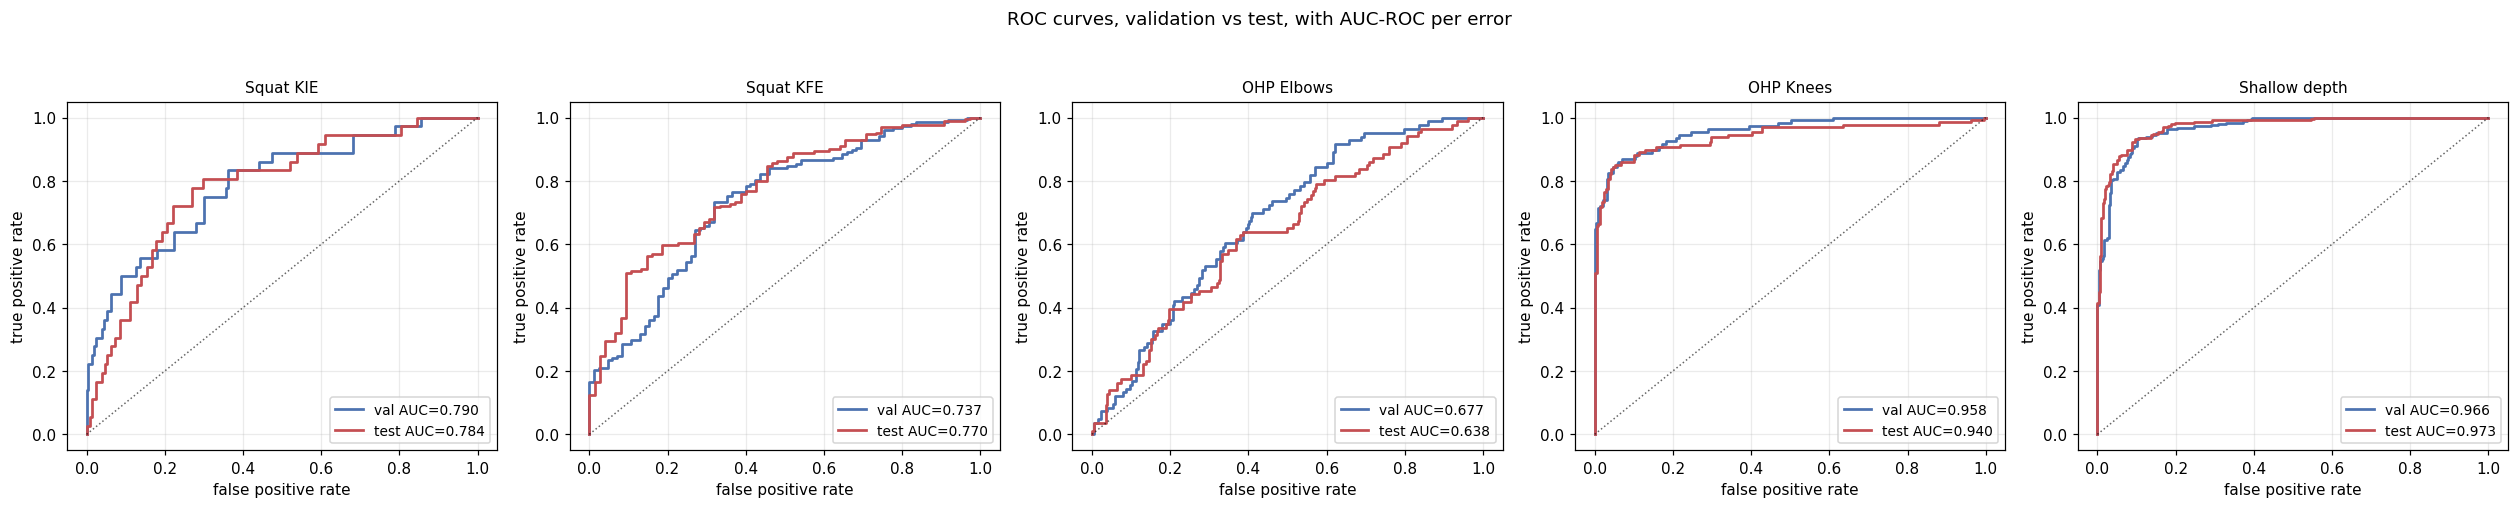

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve  # noqa: E402

roc_rows = [
    ("Squat KIE", svl[:, 0], sv[:, 0], stl[:, 0], st[:, 0]),
    ("Squat KFE", svl[:, 1], sv[:, 1], stl[:, 1], st[:, 1]),
    ("OHP Elbows", ovl[:, 0], ov[:, 0], otl[:, 0], ot[:, 0]),
    ("OHP Knees", ovl[:, 1], ov[:, 1], otl[:, 1], ot[:, 1]),
    ("Shallow depth", SHAL["val_labels"], SHAL["ensemble_val_scores"],
     SHAL["test_labels"], SHAL["ensemble_test_scores"]),
]
print(f"{'error':16s} {'val AUC-ROC':>12s} {'test AUC-ROC':>13s} {'gap':>8s}   {'test PR-AUC (ref)':>18s}")
print("-" * 74)
fig, axes = plt.subplots(1, 5, figsize=(23, 4.4))
for ax, (name, vlab, vsc, tlab, tsc) in zip(axes, roc_rows):
    v_auc, t_auc = roc_auc_score(vlab, vsc), roc_auc_score(tlab, tsc)
    for lab, sc, split, color in [(vlab, vsc, "val", C_VAL), (tlab, tsc, "test", C_TEST)]:
        fpr, tpr_, _ = roc_curve(lab, sc)
        ax.plot(fpr, tpr_, color=color, lw=1.8, label=f"{split} AUC={roc_auc_score(lab, sc):.3f}")
    ax.plot([0, 1], [0, 1], "k:", lw=1, alpha=0.6)
    ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
    ax.set_title(name, fontsize=10); ax.legend(loc="lower right", fontsize=9)
    print(f"{name:16s} {v_auc:12.3f} {t_auc:13.3f} {v_auc-t_auc:+8.3f} {pr_auc_per_error(tlab, tsc):18.3f}")
plt.suptitle("ROC curves, validation vs test, with AUC-ROC per error", y=1.04)
savefig("roc_curves")

## Section C3. Train vs validation vs test F1 at the deployed checkpoint

Each model is run on the official train, validation and test splits at the val-tuned threshold.
Train F1 sits above validation and test for any trained model, since the model has seen the
training data; that gap on its own is not overfitting. Two things matter: (a) validation close to
test, which means the deployed operating point generalizes to unseen data, and (b) the size of the
train-to-test gap. Validation tracks test for every deployed error (no validation-to-test
overfitting). The rare, hard classes (Squat KIE, OHP Elbows) show large train-to-test gaps: the
model fits training examples of those errors much better than unseen ones (train-memorization).
SSL reduces this gap sharply on OHP Elbows (baseline +0.53 to deployed +0.13) but not on Squat KIE,
where it raises test F1 while the train-to-test gap stays large. Produced by train_eval.py.

model and error              train     val    test  train-test  role
------------------------------------------------------------------------
Squat MD-SSL - KIE          0.9326  0.5000  0.4198     +0.5128  deployed
Squat MD-SSL - KFE          0.8535  0.8128  0.8410     +0.0125  deployed
OHP MD-SSL - Elbows         0.5761  0.4780  0.4474     +0.1287  deployed
OHP MD-SSL - Knees          0.9842  0.8683  0.8770     +0.1071  deployed
Shallow CVCSPC - depth      0.9712  0.9119  0.8902     +0.0810  deployed
Squat baseline - KIE        0.7111  0.3040  0.2857     +0.4254  control
Squat baseline - KFE        0.9277  0.7979  0.8000     +0.1277  control
OHP baseline - Elbows       0.9420  0.5146  0.4167     +0.5253  control
OHP baseline - Knees        0.9907  0.7980  0.8069     +0.1839  control
Shallow baseline - depth    0.9824  0.8942  0.8750     +0.1074  control


  saved docs\figures\audit_train_val_test_f1.png


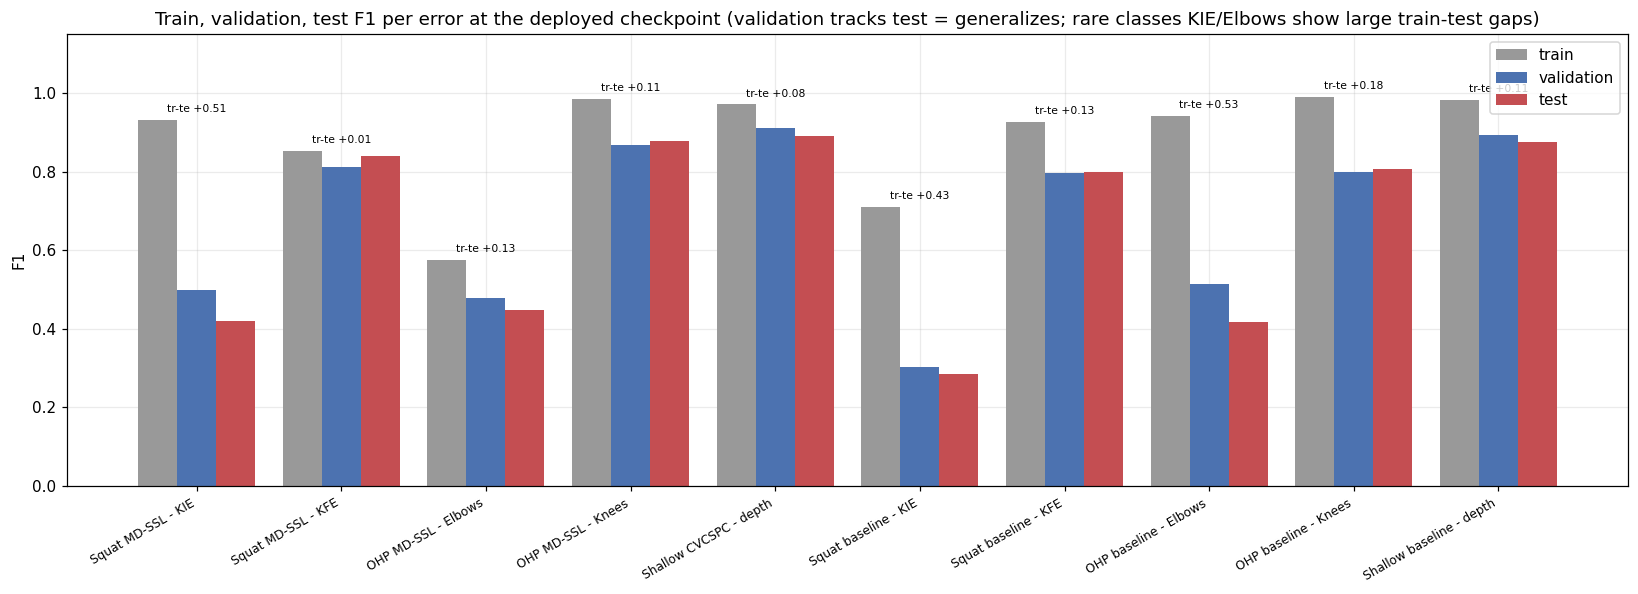

In [7]:
_tvt_path = ROOT / "docs/audit/data/train_val_test_f1.pkl"
if _tvt_path.exists():
    _tvt = pickle.loads(_tvt_path.read_bytes())
    _order = ["Squat MD-SSL - KIE", "Squat MD-SSL - KFE", "OHP MD-SSL - Elbows", "OHP MD-SSL - Knees",
              "Shallow CVCSPC - depth", "Squat baseline - KIE", "Squat baseline - KFE",
              "OHP baseline - Elbows", "OHP baseline - Knees", "Shallow baseline - depth"]
    _rows = [(k, _tvt[k]) for k in _order if k in _tvt]
    print(f"{'model and error':26s} {'train':>7s} {'val':>7s} {'test':>7s} {'train-test':>11s}  role")
    print("-" * 72)
    for k, r in _rows:
        role = "deployed" if r.get("deployed") else "control"
        print(f"{k:26s} {r['train']:7.4f} {r['val']:7.4f} {r['test']:7.4f} {r['train']-r['test']:+11.4f}  {role}")
    labels = [k for k, _ in _rows]
    tr = [r["train"] for _, r in _rows]; vl = [r["val"] for _, r in _rows]; te = [r["test"] for _, r in _rows]
    x = np.arange(len(_rows)); w = 0.27
    fig, ax = plt.subplots(figsize=(max(12, 1.5 * len(_rows)), 5.5))
    ax.bar(x - w, tr, w, color="#999999", label="train")
    ax.bar(x, vl, w, color=C_VAL, label="validation")
    ax.bar(x + w, te, w, color=C_TEST, label="test")
    for xi, (_, r) in enumerate(_rows):
        ax.text(xi, max(r["train"], r["val"], r["test"]) + 0.02, f"tr-te {r['train']-r['test']:+.2f}",
                ha="center", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("F1"); ax.set_ylim(0, 1.15); ax.legend(loc="upper right")
    ax.set_title("Train, validation, test F1 per error at the deployed checkpoint "
                 "(validation tracks test = generalizes; rare classes KIE/Elbows show large train-test gaps)")
    savefig("train_val_test_f1")
else:
    print("train_val_test_f1.pkl not present yet; run docs/audit/train_eval.py to generate it.")

## Section D. Confusion matrices on validation and test (production threshold)

A model that generalizes makes structurally similar errors on validation and test. Counts are shown
with row-normalized rates in parentheses; layout is sklearn [[TN, FP], [FN, TP]].

  saved docs\figures\audit_squat_ohp_confusion.png


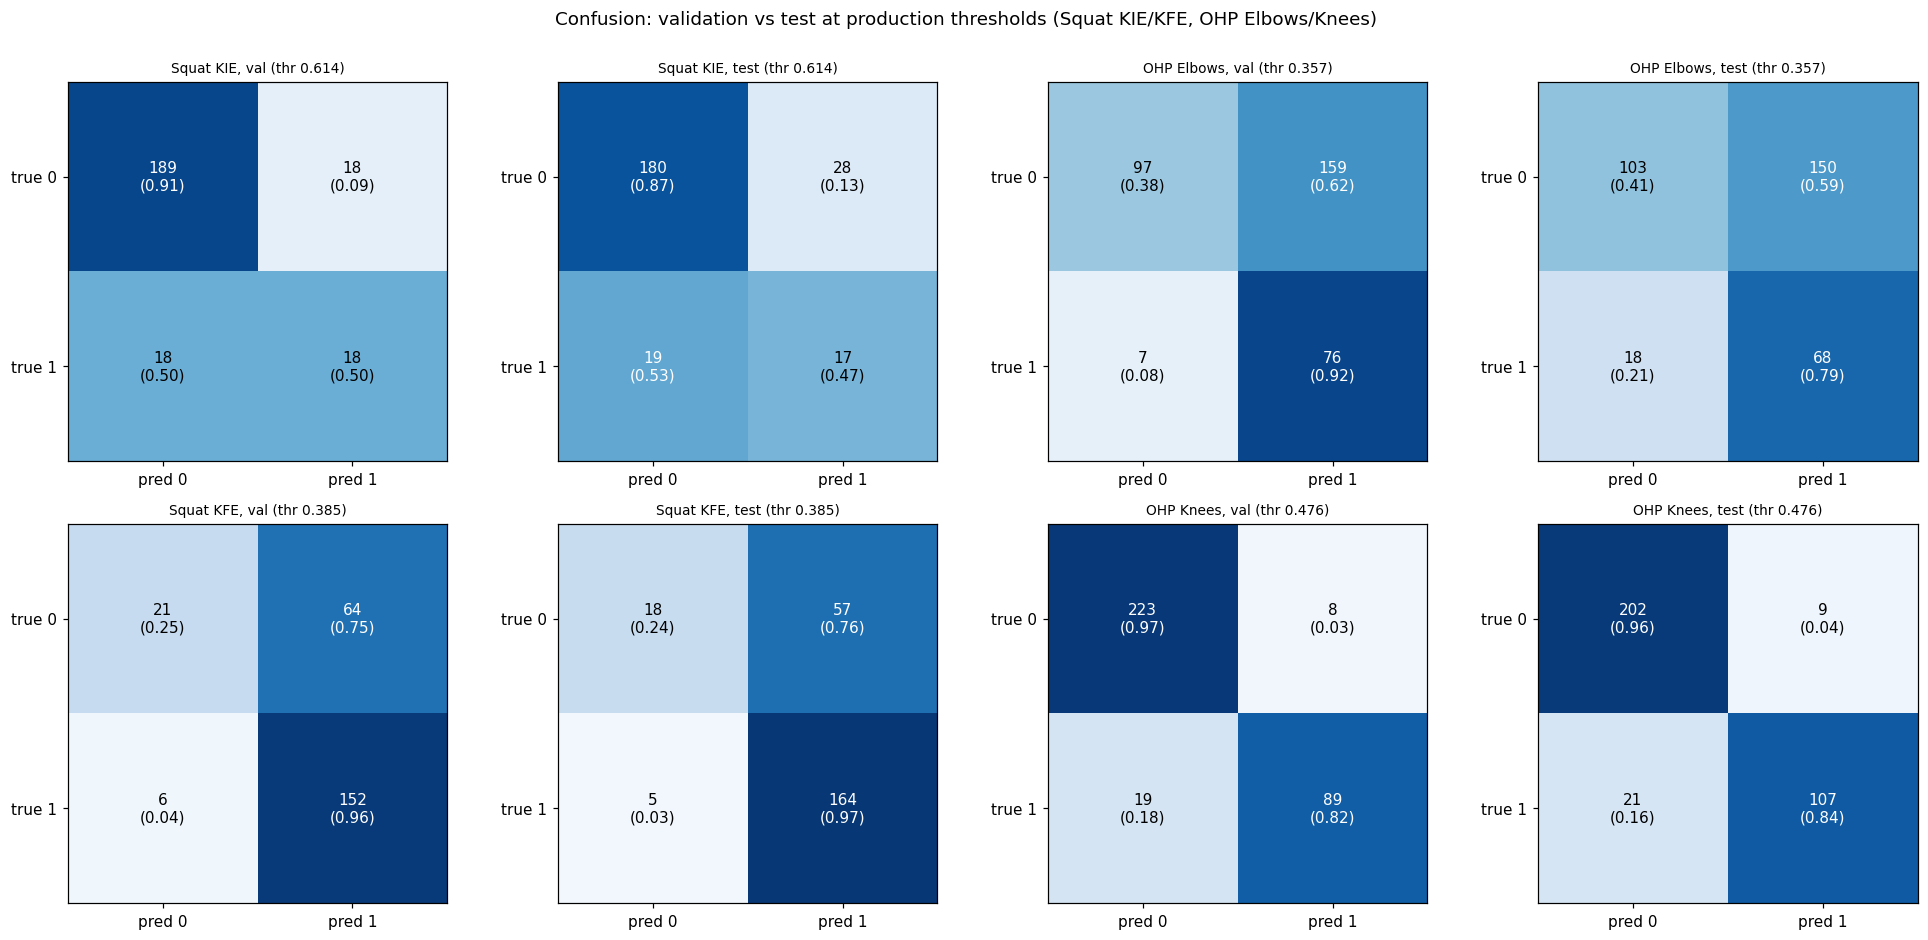

  saved docs\figures\audit_shallow_confusion.png


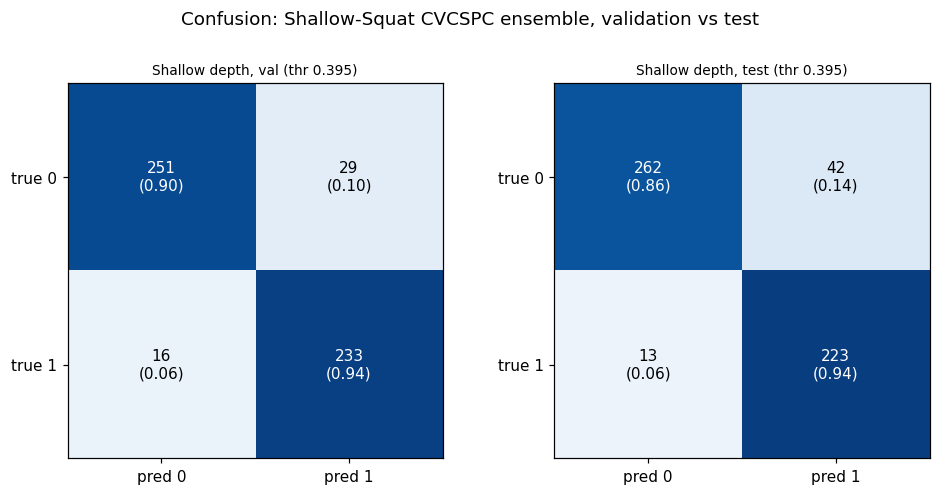

In [8]:
def conf_pair(ax_v, ax_t, vlab, vsc, tlab, tsc, thr, title):
    for ax, lab, sc, split in [(ax_v, vlab, vsc, "val"), (ax_t, tlab, tsc, "test")]:
        cm = confusion_matrix_per_error(lab, (sc >= thr).astype(int))
        rn = cm / cm.sum(1, keepdims=True).clip(min=1)
        ax.imshow(rn, cmap="Blues", vmin=0, vmax=1)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i,j]}\n({rn[i,j]:.2f})", ha="center", va="center",
                        color="white" if rn[i, j] > 0.5 else "black", fontsize=10)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["pred 0", "pred 1"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["true 0", "true 1"])
        ax.set_title(f"{title}, {split} (thr {thr:.3f})", fontsize=9)
        ax.grid(False)


fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))
for r, (ci, err) in enumerate([(0, "KIE"), (1, "KFE")]):
    thr = SQUAT["final"]["thresholds"][err]
    conf_pair(axes[r, 0], axes[r, 1], svl[:, ci], sv[:, ci], stl[:, ci], st[:, ci], thr, f"Squat {err}")
for r, (ci, err) in enumerate([(0, "Elbows"), (1, "Knees")]):
    thr = OHP["thresholds"][err.lower()]
    conf_pair(axes[r, 2], axes[r, 3], ovl[:, ci], ov[:, ci], otl[:, ci], ot[:, ci], thr, f"OHP {err}")
plt.suptitle("Confusion: validation vs test at production thresholds (Squat KIE/KFE, OHP Elbows/Knees)", y=1.0)
savefig("squat_ohp_confusion")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.3))
thr = SHAL["best_threshold"]
conf_pair(axes[0], axes[1], SHAL["val_labels"], SHAL["ensemble_val_scores"],
          SHAL["test_labels"], SHAL["ensemble_test_scores"], thr, "Shallow depth")
plt.suptitle("Confusion: Shallow-Squat CVCSPC ensemble, validation vs test", y=1.02)
savefig("shallow_confusion")

## Section E. Score distributions (positives vs negatives) on validation and test

Class separation that looks the same on validation and test indicates the decision surface
transfers. The overlap on the rare hard class (Squat KIE) is shown as-is; the point is that
validation and test overlap the same way, not that every error separates perfectly.

  saved docs\figures\audit_squat_ohp_score_dist.png


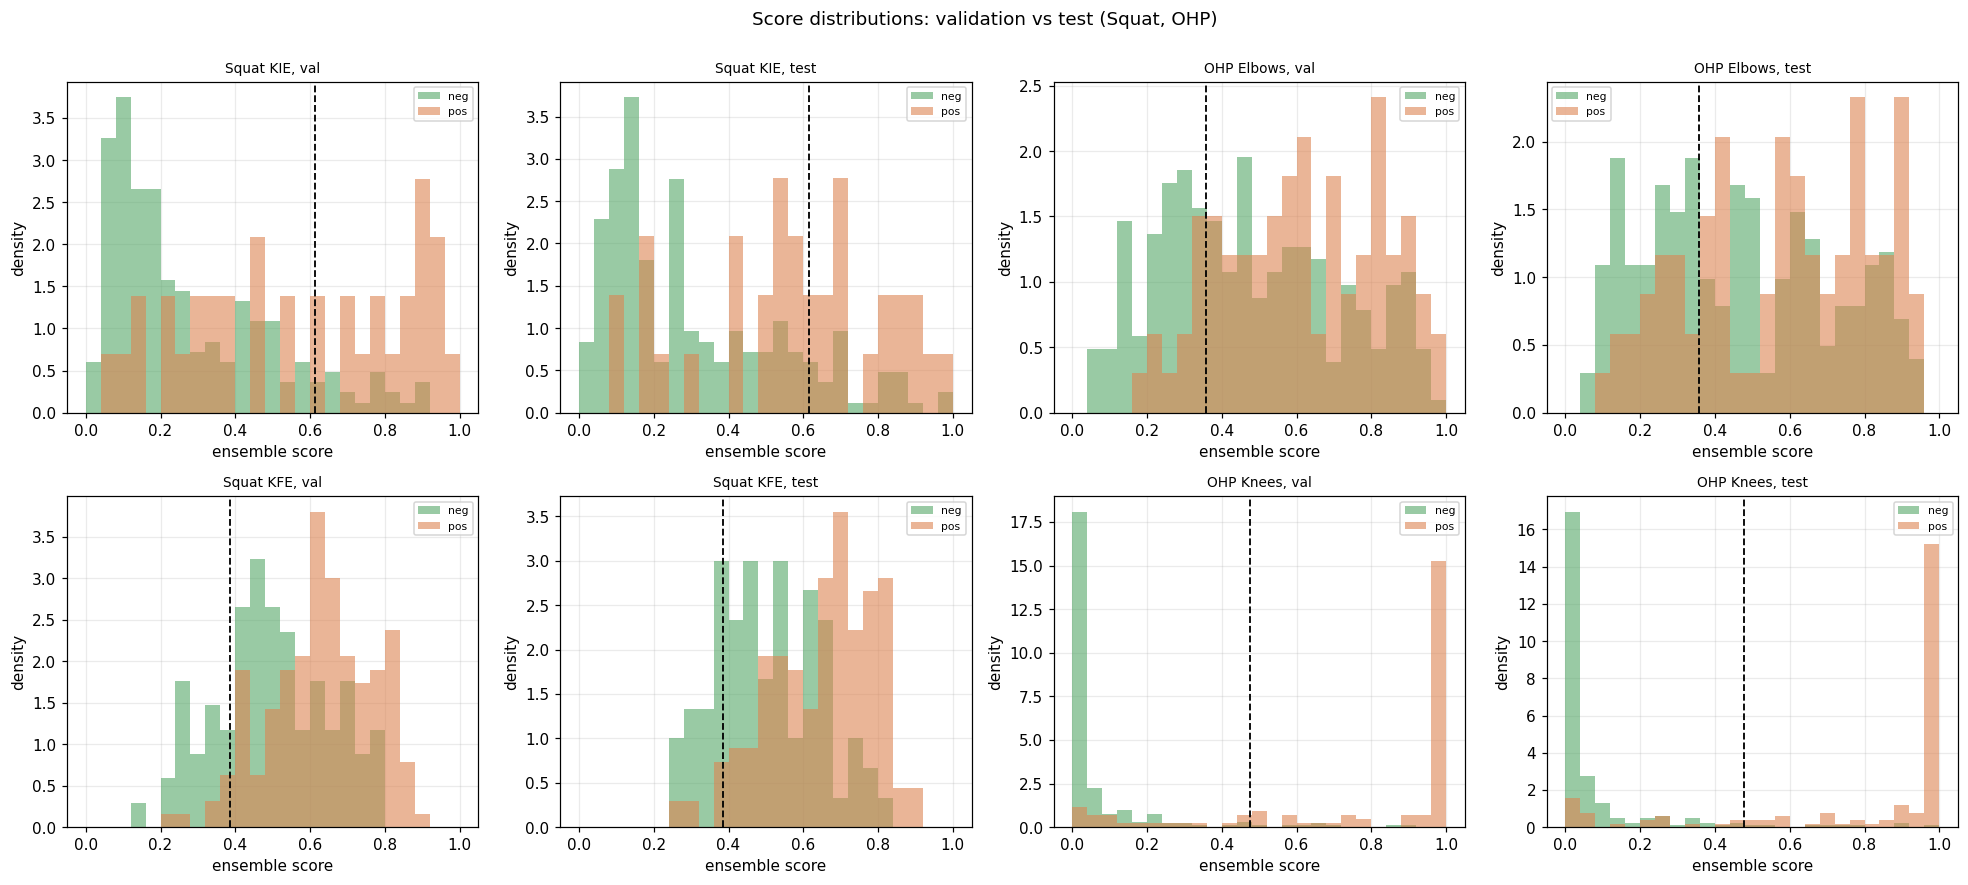

  saved docs\figures\audit_shallow_score_dist.png


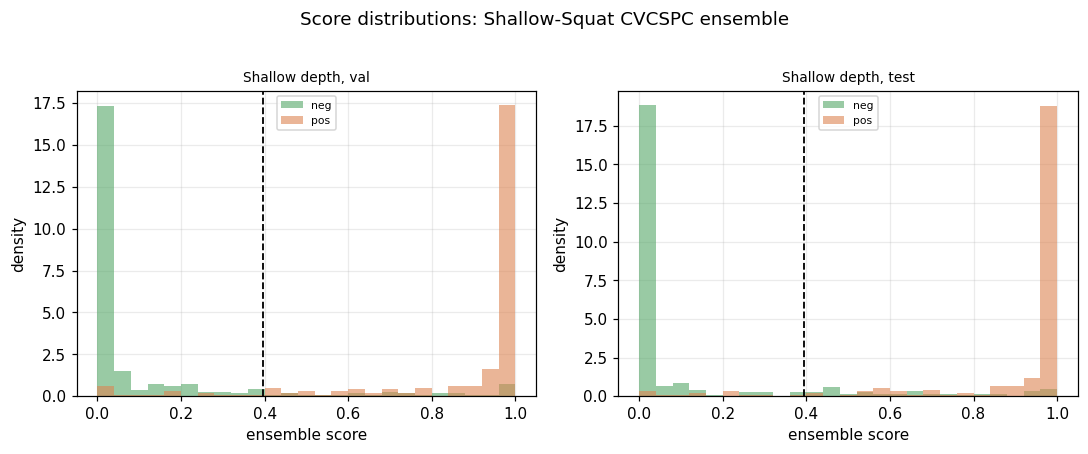

In [9]:
def score_hist(ax, lab, sc, thr, title, split):
    lab = np.asarray(lab); sc = np.asarray(sc)
    bins = np.linspace(0, 1, 26)
    ax.hist(sc[lab == 0], bins=bins, color=C_NEG, alpha=0.6, label="neg", density=True)
    ax.hist(sc[lab == 1], bins=bins, color=C_POS, alpha=0.6, label="pos", density=True)
    ax.axvline(thr, color="k", ls="--", lw=1.2)
    ax.set_title(f"{title}, {split}", fontsize=9)
    ax.set_xlabel("ensemble score"); ax.set_ylabel("density")
    ax.legend(fontsize=7)


fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for r, (ci, err) in enumerate([(0, "KIE"), (1, "KFE")]):
    thr = SQUAT["final"]["thresholds"][err]
    score_hist(axes[r, 0], svl[:, ci], sv[:, ci], thr, f"Squat {err}", "val")
    score_hist(axes[r, 1], stl[:, ci], st[:, ci], thr, f"Squat {err}", "test")
for r, (ci, err) in enumerate([(0, "Elbows"), (1, "Knees")]):
    thr = OHP["thresholds"][err.lower()]
    score_hist(axes[r, 2], ovl[:, ci], ov[:, ci], thr, f"OHP {err}", "val")
    score_hist(axes[r, 3], otl[:, ci], ot[:, ci], thr, f"OHP {err}", "test")
plt.suptitle("Score distributions: validation vs test (Squat, OHP)", y=1.0)
savefig("squat_ohp_score_dist")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
thr = SHAL["best_threshold"]
score_hist(axes[0], SHAL["val_labels"], SHAL["ensemble_val_scores"], thr, "Shallow depth", "val")
score_hist(axes[1], SHAL["test_labels"], SHAL["ensemble_test_scores"], thr, "Shallow depth", "test")
plt.suptitle("Score distributions: Shallow-Squat CVCSPC ensemble", y=1.02)
savefig("shallow_score_dist")

## Section F. Per-seed variance (test F1 spread)

Low, consistent per-seed test F1 indicates the result is not an artifact of a single lucky seed.
The ensemble value is marked.

  saved docs\figures\audit_per_seed_variance.png


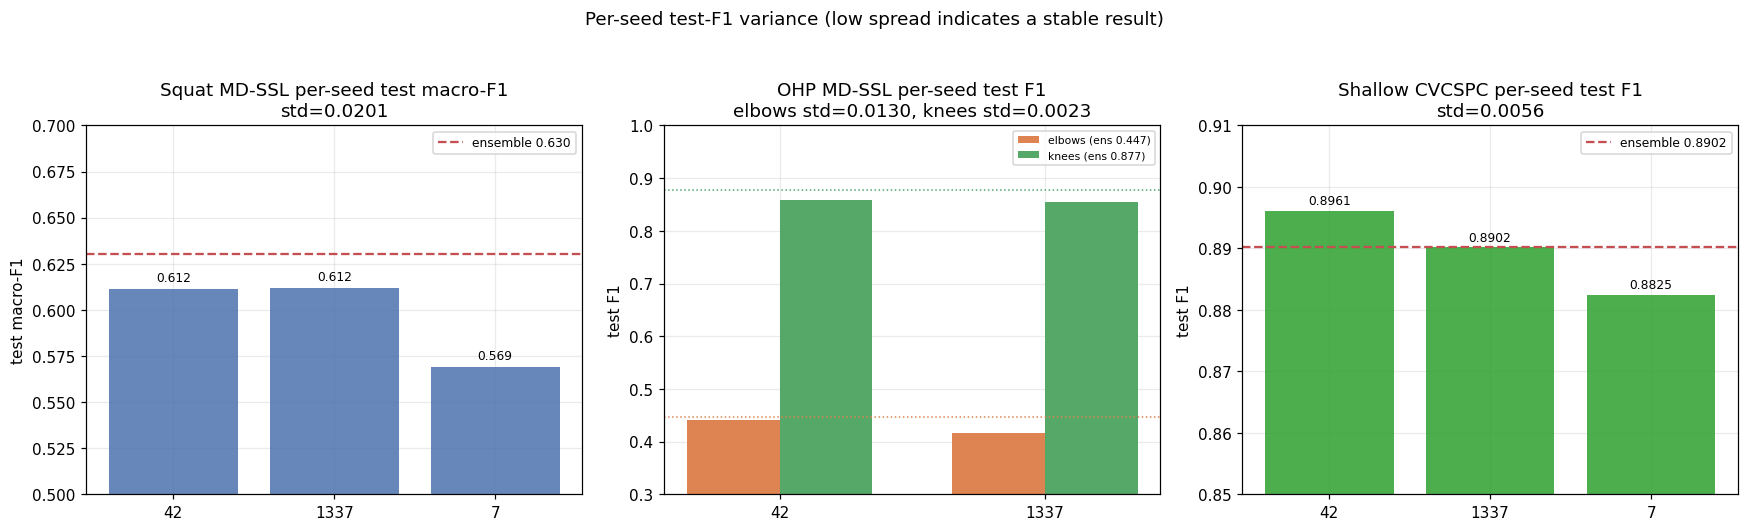

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

ax = axes[0]
seeds = list(SQUAT["per_seed"].keys())
macro = [SQUAT["per_seed"][s]["macro"] for s in seeds]
ax.bar([str(s) for s in seeds], macro, color=C_VAL, alpha=0.85)
ax.axhline(SQUAT["final"]["test_macro"], color=C_TEST, ls="--", label=f"ensemble {SQUAT['final']['test_macro']:.3f}")
ax.set_title(f"Squat MD-SSL per-seed test macro-F1\nstd={np.std(macro):.4f}")
ax.set_ylabel("test macro-F1"); ax.set_ylim(0.5, 0.7); ax.legend(fontsize=8)
for i, m in enumerate(macro):
    ax.text(i, m + 0.004, f"{m:.3f}", ha="center", fontsize=8)

ax = axes[1]
oseeds = list(OHP["per_seed_test_f1"].keys())
elb = [OHP["per_seed_test_f1"][s]["elbows"] for s in oseeds]
kn = [OHP["per_seed_test_f1"][s]["knees"] for s in oseeds]
xx = np.arange(len(oseeds)); w = 0.35
ax.bar(xx - w / 2, elb, w, color="#DD8452", label=f"elbows (ens {OHP['test_f1']['elbows']:.3f})")
ax.bar(xx + w / 2, kn, w, color="#55A868", label=f"knees (ens {OHP['test_f1']['knees']:.3f})")
ax.axhline(OHP["test_f1"]["elbows"], color="#DD8452", ls=":", lw=1)
ax.axhline(OHP["test_f1"]["knees"], color="#55A868", ls=":", lw=1)
ax.set_xticks(xx); ax.set_xticklabels([str(s) for s in oseeds])
ax.set_title(f"OHP MD-SSL per-seed test F1\nelbows std={np.std(elb):.4f}, knees std={np.std(kn):.4f}")
ax.set_ylabel("test F1"); ax.set_ylim(0.3, 1.0); ax.legend(fontsize=7)

ax = axes[2]
sseeds = SHAL["seeds"]
cv = [SHAL["test_f1"]["per_seed"][s] for s in sseeds]
ax.bar([str(s) for s in sseeds], cv, color="#2CA02C", alpha=0.85)
ax.axhline(SHAL["test_f1"]["cvcspc_ensemble"], color=C_TEST, ls="--",
           label=f"ensemble {SHAL['test_f1']['cvcspc_ensemble']:.4f}")
ax.set_title(f"Shallow CVCSPC per-seed test F1\nstd={np.std(cv):.4f}")
ax.set_ylabel("test F1"); ax.set_ylim(0.85, 0.91); ax.legend(fontsize=8)
for i, m in enumerate(cv):
    ax.text(i, m + 0.001, f"{m:.4f}", ha="center", fontsize=8)
plt.suptitle("Per-seed test-F1 variance (low spread indicates a stable result)", y=1.04)
savefig("per_seed_variance")

## Section G. SSL pretraining health (no representation collapse)

For the video MD-SSL backbones, effective_rank should stay well above the collapse floor of 1 and
embedding_std above 0, and the linear-probe F1 should beat chance; collapse would drive these to
zero. For the image CVCSPC backbone, the triplet-accuracy monitor rises toward 1 as the contrastive
task is learned. The fine-tune then early-stops before overfitting (Section B).

  saved docs\figures\audit_ssl_health.png


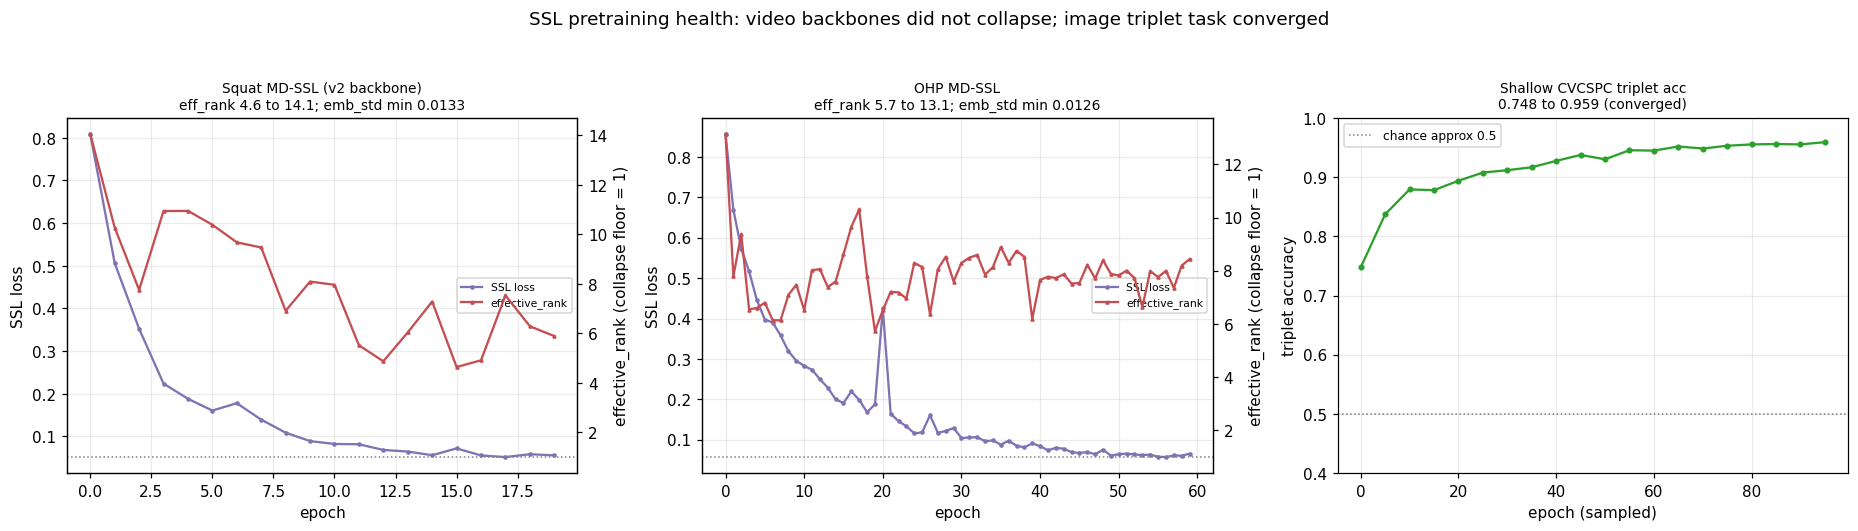

  saved docs\figures\audit_ssl_linear_probe.png


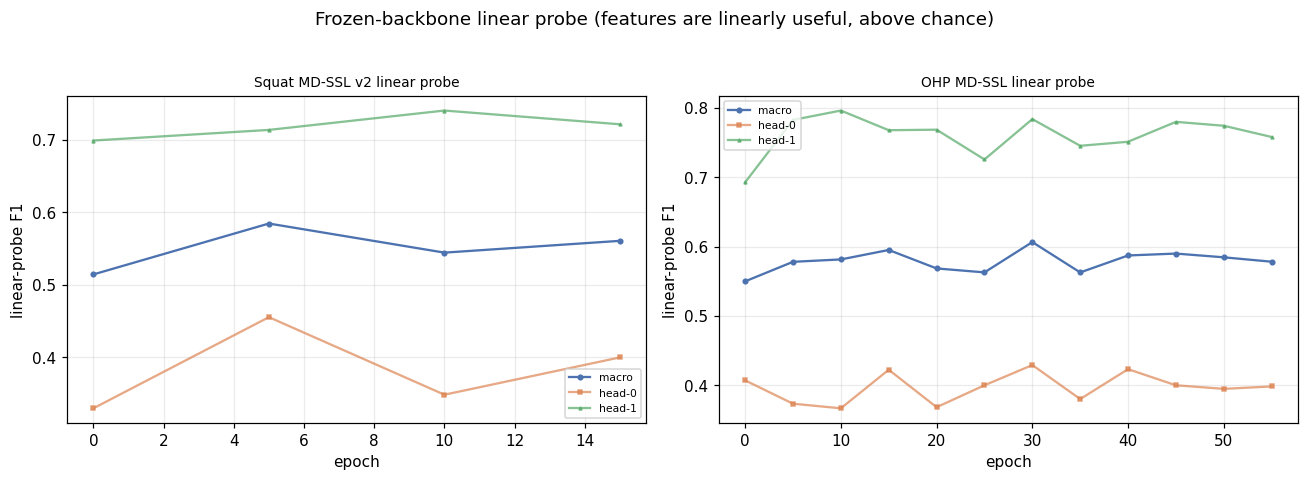

In [11]:
def ssl_panel(ax, metrics, title, rank_key="effective_rank"):
    ep = [m["epoch"] for m in metrics]
    ax.plot(ep, [m["ssl_loss_mean"] for m in metrics], color=C_TRAIN, marker="o", ms=2, label="SSL loss")
    ax.set_xlabel("epoch"); ax.set_ylabel("SSL loss")
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(ep, [m[rank_key] for m in metrics], color=C_TEST, marker="^", ms=2, label="effective_rank")
    ax2.axhline(1.0, color="gray", ls=":", lw=1)
    ax2.set_ylabel("effective_rank (collapse floor = 1)")
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=7, loc="center right")
    er = [m[rank_key] for m in metrics]
    es = [m["embedding_std"] for m in metrics]
    ax.set_title(f"{title}\neff_rank {min(er):.1f} to {max(er):.1f}; emb_std min {min(es):.4f}", fontsize=9)


fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
ssl_panel(axes[0], SQUAT["ssl_v2"]["metrics"], "Squat MD-SSL (v2 backbone)")
ssl_panel(axes[1], OHP["ssl_metrics_history"], "OHP MD-SSL")
ax = axes[2]
tep = [m["epoch"] for m in SHAL["ssl_triplet_acc"]]
tac = [m["triplet_acc"] for m in SHAL["ssl_triplet_acc"]]
ax.plot(tep, tac, color="#2CA02C", marker="o", ms=3)
ax.axhline(0.5, color="gray", ls=":", lw=1, label="chance approx 0.5")
ax.set_xlabel("epoch (sampled)"); ax.set_ylabel("triplet accuracy")
ax.set_ylim(0.4, 1.0); ax.legend(fontsize=8)
ax.set_title(f"Shallow CVCSPC triplet acc\n{tac[0]:.3f} to {tac[-1]:.3f} (converged)", fontsize=9)
plt.suptitle("SSL pretraining health: video backbones did not collapse; image triplet task converged", y=1.04)
savefig("ssl_health")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, probe, title in [
    (axes[0], SQUAT["ssl_v2"]["linear_probe"], "Squat MD-SSL v2 linear probe"),
    (axes[1], OHP["ssl_linear_probe_history"], "OHP MD-SSL linear probe")]:
    ep = [p["epoch"] for p in probe]
    ax.plot(ep, [p["linear_probe_f1_macro"] for p in probe], color=C_VAL, marker="o", ms=3, label="macro")
    ax.plot(ep, [p["linear_probe_f1_kie"] for p in probe], color="#DD8452", marker="s", ms=2, alpha=0.7, label="head-0")
    ax.plot(ep, [p["linear_probe_f1_kfe"] for p in probe], color="#55A868", marker="^", ms=2, alpha=0.7, label="head-1")
    ax.set_xlabel("epoch"); ax.set_ylabel("linear-probe F1"); ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Frozen-backbone linear probe (features are linearly useful, above chance)", y=1.03)
savefig("ssl_linear_probe")

## Section H. Headline F1 vs supervised baseline vs published paper

The deployed SSL ensembles match or beat the published Parmar et al. (ECCV 2022) numbers on the
identical metric and split, and beat the supervised control. The SSL regularization is also what
closes the baseline generalization gap (Sections B and C).

  saved docs\figures\audit_headline_vs_paper.png


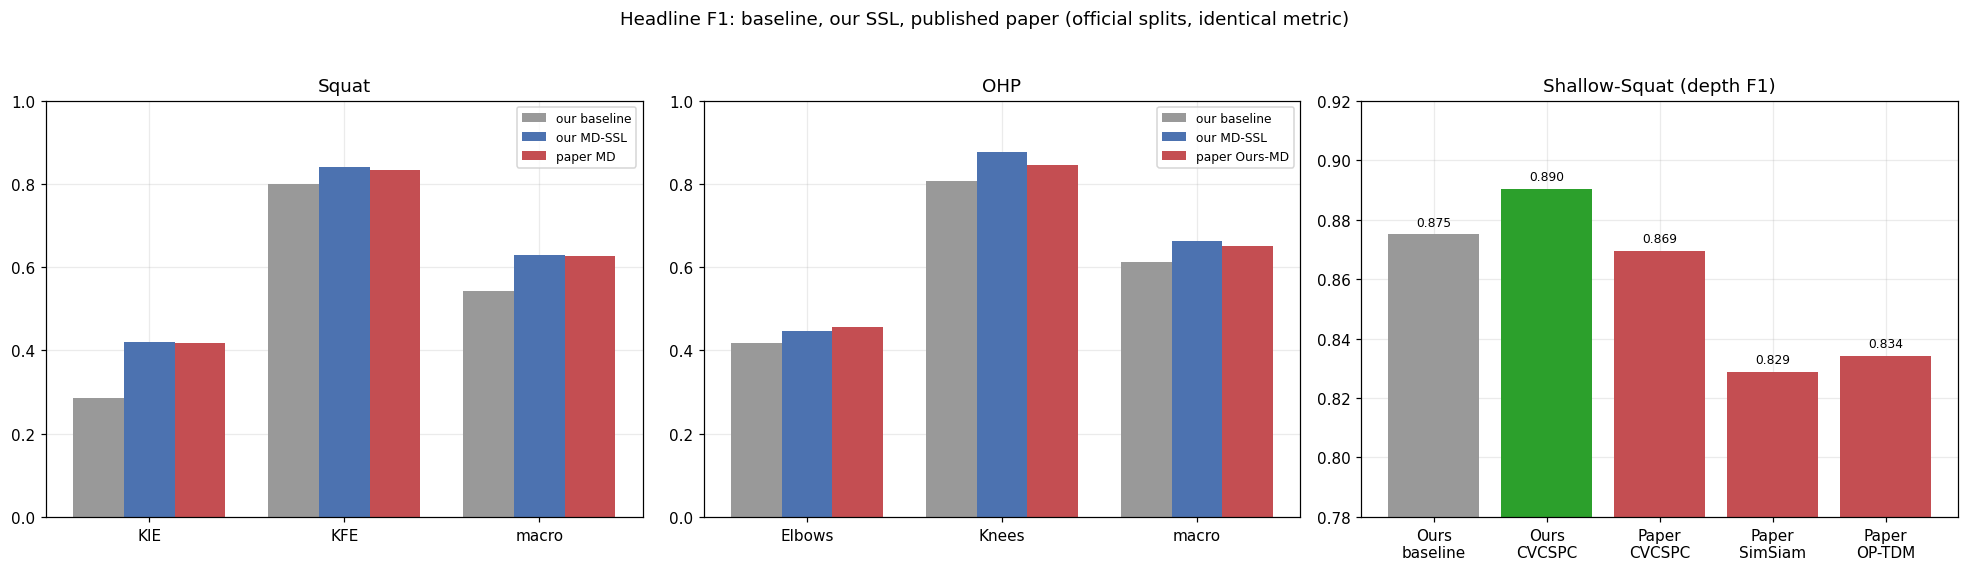

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
cats = ["KIE", "KFE", "macro"]; xx = np.arange(3); w = 0.26
ours = [SQUAT["final"]["test_f1"]["KIE"], SQUAT["final"]["test_f1"]["KFE"], SQUAT["final"]["test_macro"]]
base = [SQUAT["comparison"]["phase3"]["KIE"], SQUAT["comparison"]["phase3"]["KFE"], SQUAT["comparison"]["phase3"]["macro"]]
paper = [SQUAT["comparison"]["paper_md"]["KIE"], SQUAT["comparison"]["paper_md"]["KFE"], SQUAT["comparison"]["paper_md"]["macro"]]
ax.bar(xx - w, base, w, color="#999999", label="our baseline")
ax.bar(xx, ours, w, color=C_VAL, label="our MD-SSL")
ax.bar(xx + w, paper, w, color=C_TEST, label="paper MD")
ax.set_xticks(xx); ax.set_xticklabels(cats); ax.set_ylim(0, 1.0); ax.set_title("Squat"); ax.legend(fontsize=8)

ax = axes[1]
cats = ["Elbows", "Knees", "macro"]
ours = [OHP["test_f1"]["elbows"], OHP["test_f1"]["knees"], OHP["test_f1"]["macro"]]
base = [OHP["baseline_control"]["elbows"], OHP["baseline_control"]["knees"], OHP["baseline_control"]["macro"]]
paper = [OHP["paper_targets"]["elbows"], OHP["paper_targets"]["knees"],
         (OHP["paper_targets"]["elbows"] + OHP["paper_targets"]["knees"]) / 2]
ax.bar(xx - w, base, w, color="#999999", label="our baseline")
ax.bar(xx, ours, w, color=C_VAL, label="our MD-SSL")
ax.bar(xx + w, paper, w, color=C_TEST, label="paper Ours-MD")
ax.set_xticks(xx); ax.set_xticklabels(cats); ax.set_ylim(0, 1.0); ax.set_title("OHP"); ax.legend(fontsize=8)

ax = axes[2]
methods = ["Ours\nbaseline", "Ours\nCVCSPC", "Paper\nCVCSPC", "Paper\nSimSiam", "Paper\nOP-TDM"]
vals = [SHAL["baseline_control"]["test_f1"], SHAL["test_f1"]["cvcspc_ensemble"],
        SHAL["paper_targets"]["cvcspc"], SHAL["paper_targets"]["simsiam"], SHAL["paper_targets"]["openpose_tdm"]]
ax.bar(methods, vals, color=["#999999", "#2CA02C", C_TEST, C_TEST, C_TEST])
for i, v in enumerate(vals):
    ax.text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=8)
ax.set_ylim(0.78, 0.92); ax.set_title("Shallow-Squat (depth F1)")
plt.suptitle("Headline F1: baseline, our SSL, published paper (official splits, identical metric)", y=1.03)
savefig("headline_vs_paper")

## Section Z. Scoreboard

One row per audited model and error: the held-out F1 gap, the threshold-free PR-AUC gap, and the
generalization verdict. Deployed models are summarized separately from the controls. The OHP
baseline is the expected REVIEW row (it overfits Elbows). The weight re-evaluation match is in
docs/eval/OVERFITTING_AUDIT.md.

In [13]:
print(f"{'model and error':24s} {'F1 gap':>8s} {'PRAUC gap':>10s} {'role':>10s}  generalizes?")
print("-" * 66)
for r in gap_rows:
    pg = "   n/a" if np.isnan(r["prauc_gap"]) else f"{r['prauc_gap']:+.4f}"
    role = "deployed" if r["deployed"] else "control"
    print(f"{r['label']:24s} {r['f1_gap']:+8.4f} {pg:>10s} {role:>10s}  {'YES' if r['ok'] else 'REVIEW'}")
print("-" * 66)
deployed_ok = all(r["ok"] for r in gap_rows if r["deployed"])
controls_review = [r["label"] for r in gap_rows if not r["deployed"] and not r["ok"]]
print("Deployed models:", "all generalize [OK]" if deployed_ok else "REVIEW (investigate)")
print("Controls flagged as overfitting (expected):", controls_review or "none")
print("\nFigures written to docs/figures/audit_*.png")

model and error            F1 gap  PRAUC gap       role  generalizes?
------------------------------------------------------------------
Squat MD-SSL - KIE        +0.0802    +0.1320   deployed  YES
Squat MD-SSL - KFE        -0.0282    -0.0469   deployed  YES
Squat baseline - KIE      +0.0183    -0.0707    control  YES
Squat baseline - KFE      -0.0021    -0.0621    control  YES
OHP MD-SSL - Elbows       +0.0306    -0.0012   deployed  YES
OHP MD-SSL - Knees        -0.0088    +0.0015   deployed  YES
Shallow CVCSPC - depth    +0.0217    -0.0048   deployed  YES
Shallow baseline - depth  +0.0192        n/a    control  YES
OHP baseline - Elbows     +0.0979    +0.0414    control  REVIEW
OHP baseline - Knees      -0.0089    -0.0270    control  YES
------------------------------------------------------------------
Deployed models: all generalize [OK]
Controls flagged as overfitting (expected): ['OHP baseline - Elbows']

Figures written to docs/figures/audit_*.png
